# Foodland Wudinna — Full Department EDA (2026 YTD)
**Period:** 1 January 2026 – 23 April 2026 · **92 trading days**

**Data sources:**
- `foodland_data.db` — `fact_sales` (POS exports, FV department)
- `01_data/raw/Dump/Dump Stock Report (3).xlsx` — GAP POS full write-offs (all depts)
- `01_data/raw/Markdown/Markdown Report.xlsx` — GAP POS discounted sales (all depts)

**Sections:**
1. Setup & data loading
2. FV department overview
3. Sub-department analysis (Fruit · Vegetables · Potatoes · Salads)
4. Day-of-week demand patterns
5. ABC item classification
6. Margin analysis — low-GP items and margin traps
7. Waste: Dump Stock analysis (all departments)
8. Waste: Markdown analysis (all departments)
9. Combined waste picture
10. Key findings & recommendations


## 1. Setup & Data Loading

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})
COLORS = {
    'Fruit':       '#e07b39',
    'Vegetables':  '#4a8c3f',
    'Potatoes':    '#c4a35a',
    'Salads':      '#6dbf9e',
    'Open':        '#aaaaaa',
    'DAIRY':       '#5b9bd5',
    'MEAT':        '#c0504d',
    'FRUIT & VEG': '#9bbb59',
}
PERIOD_START = '2026-01-01'
PERIOD_END   = '2026-04-23'
TRADING_DAYS = 92


In [2]:
# ── Resolve project root from notebook location ──────────────────────────────
from pathlib import Path
import os

# The notebook is in <project_root>/02_analysis/
# We walk up one level to find the project root regardless of Jupyter launch dir.
_nb_dir = Path(os.path.abspath(''))
PROJECT_ROOT = _nb_dir.parent if _nb_dir.name == '02_analysis' else _nb_dir
DB_PATH    = PROJECT_ROOT / 'foodland_data.db'
DUMP_PATH  = PROJECT_ROOT / '01_data' / 'raw' / 'Dump' / 'Dump Stock Report (3).xlsx'
MD_PATH    = PROJECT_ROOT / '01_data' / 'raw' / 'Markdown' / 'Markdown Report.xlsx'
CHARTS_DIR = PROJECT_ROOT / '02_analysis' / 'charts'
CHARTS_DIR.mkdir(exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"DB exists    : {DB_PATH.exists()}")
print(f"Dump exists  : {DUMP_PATH.exists()}")
print(f"MD exists    : {MD_PATH.exists()}")

con = sqlite3.connect(f'file:{DB_PATH}?immutable=1', uri=True)

# ── Load all sales 2026 YTD ───────────────────────────────────────────────────
sales = pd.read_sql(f"""
    SELECT fs.date_id AS date,
           dd.day_name, dd.day_of_week, dd.month, dd.month_name, dd.week_num,
           dp.name, dp.sub_dept,
           fs.sales_ex_gst, fs.gp_dollars, fs.gp_pct,
           fs.quantity, fs.lines
    FROM fact_sales fs
    JOIN dim_product dp ON fs.product_id = dp.product_id
    JOIN dim_date    dd ON fs.date_id    = dd.date_id
    WHERE fs.date_id >= '{PERIOD_START}'
      AND fs.date_id <= '{PERIOD_END}'
""", con)

sales['date'] = pd.to_datetime(sales['date'])
sales['sub_dept_label'] = sales['sub_dept'].fillna('None/Unknown')
print(f"Rows loaded: {len(sales):,}  |  Unique items: {sales['name'].nunique()}  |  Trading days: {sales['date'].nunique()}")


Project root : c:\Users\fabio\OneDrive\Documentos\foodland_wudinna
DB exists    : True
Dump exists  : True
MD exists    : True
Rows loaded: 9,998  |  Unique items: 244  |  Trading days: 92


In [3]:
# ── Load dump stock ───────────────────────────────────────────────────────────
dump_raw = pd.read_excel(DUMP_PATH,
                         sheet_name='Page 1', header=4)
dump_raw = dump_raw.dropna(axis=1, how='all')

# Tag departments
VALID_DEPTS = {'DAIRY', 'FRUIT & VEG', 'MEAT'}
current_dept = None
dept_col = []
for _, row in dump_raw.iterrows():
    val = str(row['Store']).strip() if pd.notna(row['Store']) else ''
    if val in VALID_DEPTS:
        current_dept = val
        dept_col.append(None)
    else:
        dept_col.append(current_dept)
dump_raw['Department'] = dept_col
dump = dump_raw[dump_raw['Store'] == 'Foodland Wudinna'].copy()
dump['Date'] = pd.to_datetime(dump['Date'], dayfirst=True, errors='coerce')
for col in ['Qty','Unit Cost ex','Unit Sell ex','Total Cost ex','Total Sell ex']:
    dump[col] = pd.to_numeric(dump[col], errors='coerce')
dump['Month'] = dump['Date'].dt.to_period('M')
print(f"Dump rows: {len(dump):,}  |  Date range: {dump['Date'].min().date()} → {dump['Date'].max().date()}")


Dump rows: 559  |  Date range: 2026-01-02 → 2026-04-23


In [4]:
# ── Load markdown report ──────────────────────────────────────────────────────
md_raw = pd.read_excel(MD_PATH,
                       sheet_name='Page 1', header=None)

SKIP_LABELS = {' ezi-manager CLOUD', 'Group Total', 'Result Total',
               'Foodland Wudinna', 'Filter: Is in Departments DAIRY, MEAT, FRUIT & VEG', 'APN'}
VALID_DEPTS_MD = {'DAIRY', 'FRUIT & VEG', 'MEAT'}

current_dept = None
records = []
col_headers = None
for i, row in md_raw.iterrows():
    val0 = str(row.iloc[0]).strip() if pd.notna(row.iloc[0]) else ''
    if val0 == 'APN':
        col_headers = [str(v).strip() if pd.notna(v) else '' for v in row.tolist()]
        continue
    if val0 in VALID_DEPTS_MD:
        current_dept = val0
        continue
    if val0 in SKIP_LABELS or val0 == '' or pd.isna(row.iloc[0]):
        continue
    try:
        int(float(str(val0).replace('.0','')))
    except:
        continue
    if current_dept and col_headers:
        record = {'Department': current_dept}
        for ci, cv in zip(col_headers, row.tolist()):
            if ci:
                record[ci] = cv
        records.append(record)

markdowns = pd.DataFrame(records)
markdowns = markdowns[[c for c in markdowns.columns if c and not c.startswith('Unnamed') and c != '']]
for col in ['Qty','Potential Sell','Total Sell','Total Cost','Discount Given','Realised Profit','GP']:
    if col in markdowns.columns:
        markdowns[col] = pd.to_numeric(markdowns[col], errors='coerce')

print(f"Markdown rows: {len(markdowns):,}  |  Departments: {markdowns['Department'].unique().tolist()}")


Markdown rows: 331  |  Departments: ['DAIRY', 'FRUIT & VEG', 'MEAT']


## 2. FV Department Overview

In [5]:
# ── Key metrics ──────────────────────────────────────────────────────────────
total_rev  = sales['sales_ex_gst'].sum()
total_gp   = sales['gp_dollars'].sum()
overall_gp = total_gp / total_rev * 100
rev_day    = total_rev / TRADING_DAYS
unique_items = sales['name'].nunique()

print("=" * 50)
print(f"  Revenue (ex GST)      : ${total_rev:>10,.2f}")
print(f"  Revenue / trading day : ${rev_day:>10,.2f}")
print(f"  Gross Profit          : ${total_gp:>10,.2f}")
print(f"  GP%                   : {overall_gp:>10.1f}%")
print(f"  Unique items traded   : {unique_items:>10}")
print(f"  Trading days          : {TRADING_DAYS:>10}")
print("=" * 50)


  Revenue (ex GST)      : $234,805.39
  Revenue / trading day : $  2,552.23
  Gross Profit          : $ 89,320.54
  GP%                   :       38.0%
  Unique items traded   :        244
  Trading days          :         92


In [6]:
# ── Sub-department revenue split ─────────────────────────────────────────────
subdept_rev = (sales.groupby('sub_dept_label')
               .agg(revenue=('sales_ex_gst','sum'), gp=('gp_dollars','sum'))
               .assign(gp_pct=lambda d: d['gp']/d['revenue']*100,
                       rev_share=lambda d: d['revenue']/d['revenue'].sum()*100)
               .sort_values('revenue', ascending=False))
print(subdept_rev.round(2).to_string())


                                revenue        gp  gp_pct  rev_share
sub_dept_label                                                      
Fruit                         115394.66  42836.61   37.12      49.14
Vegetables                     76029.30  30212.99   39.74      32.38
Potatoes                       20808.94   7929.19   38.10       8.86
Salads                         18744.51   6022.65   32.13       7.98
None/Unknown                    2286.21   2135.73   93.42       0.97
Fruit & Vege Department Open    1541.76    183.38   11.89       0.66


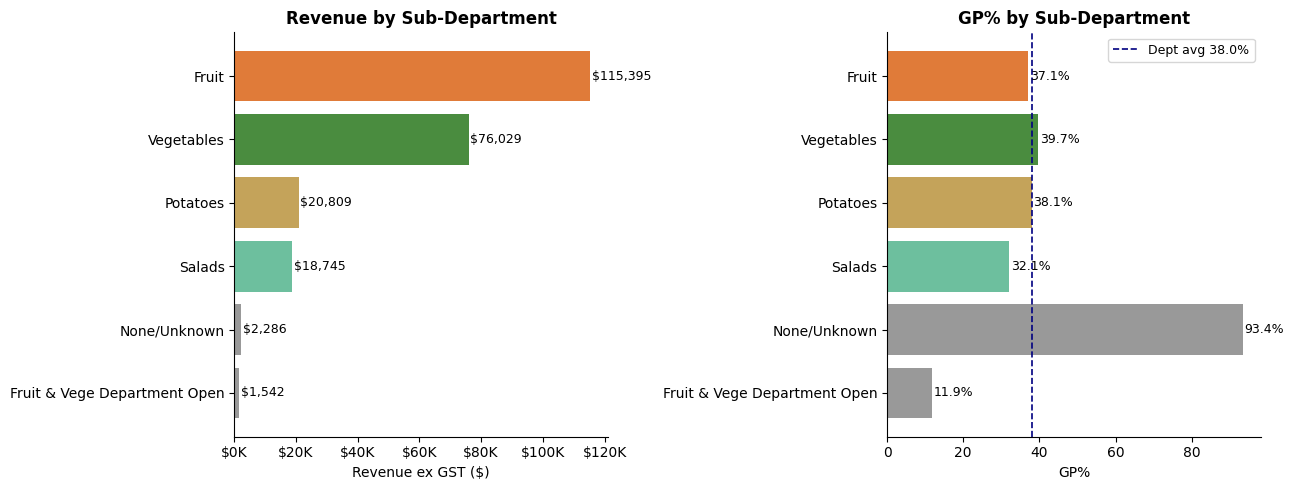

Chart saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: revenue bar
subs = subdept_rev.index.tolist()
revs = subdept_rev['revenue'].values
cols = [COLORS.get(s.split('/')[0].strip(), '#999999') for s in subs]
bars = axes[0].barh(subs[::-1], revs[::-1], color=cols[::-1])
axes[0].set_xlabel('Revenue ex GST ($)')
axes[0].set_title('Revenue by Sub-Department')
for bar, val in zip(bars, revs[::-1]):
    axes[0].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=9)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Right: GP% bar
gp_pcts = subdept_rev['gp_pct'].values
bars2 = axes[1].barh(subs[::-1], gp_pcts[::-1], color=cols[::-1])
axes[1].axvline(38.04, color='navy', linestyle='--', linewidth=1.2, label='Dept avg 38.0%')
axes[1].set_xlabel('GP%')
axes[1].set_title('GP% by Sub-Department')
axes[1].legend(fontsize=9)
for bar, val in zip(bars2, gp_pcts[::-1]):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / str(CHARTS_DIR / 'subdept_overview.png')), dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


## 3. Sub-Department Deep Dive

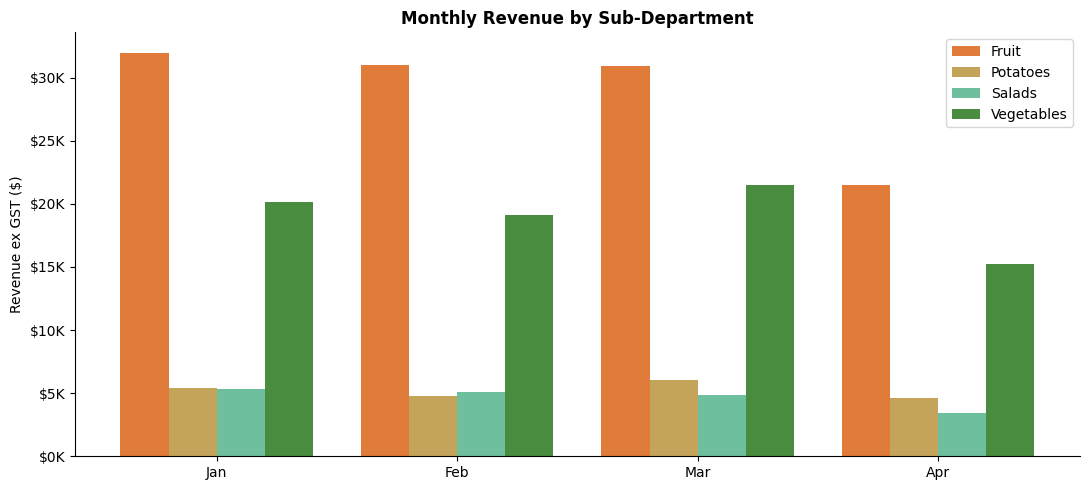

In [8]:
# ── Monthly revenue trend by sub-department ───────────────────────────────────
monthly_subdept = (sales.groupby(['month','month_name','sub_dept_label'])
                   ['sales_ex_gst'].sum().reset_index())
monthly_subdept = monthly_subdept[~monthly_subdept['sub_dept_label'].isin(['None/Unknown','Fruit & Vege Department Open'])]

pivot_rev = monthly_subdept.pivot(index='month', columns='sub_dept_label', values='sales_ex_gst').fillna(0)
pivot_rev.index = ['Jan','Feb','Mar','Apr']

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(pivot_rev))
width = 0.2
for i, col in enumerate(pivot_rev.columns):
    ax.bar(x + i*width, pivot_rev[col], width,
           label=col, color=COLORS.get(col, '#999999'))
ax.set_xticks(x + width * (len(pivot_rev.columns)-1) / 2)
ax.set_xticklabels(pivot_rev.index)
ax.set_ylabel('Revenue ex GST ($)')
ax.set_title('Monthly Revenue by Sub-Department')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / str(CHARTS_DIR / 'monthly_subdept_revenue.png')), dpi=150, bbox_inches='tight')
plt.show()


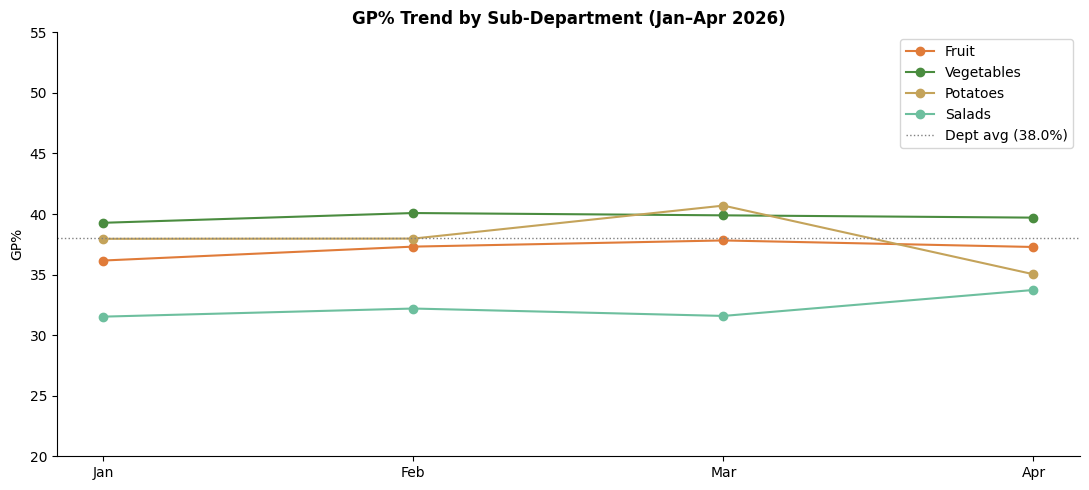

In [9]:
# ── GP% monthly trend ─────────────────────────────────────────────────────────
monthly_gp = (sales.groupby(['month','month_name','sub_dept_label'])
              .agg(rev=('sales_ex_gst','sum'), gp=('gp_dollars','sum')).reset_index())
monthly_gp['gp_pct'] = monthly_gp['gp'] / monthly_gp['rev'] * 100
monthly_gp = monthly_gp[~monthly_gp['sub_dept_label'].isin(['None/Unknown','Fruit & Vege Department Open'])]

fig, ax = plt.subplots(figsize=(11, 5))
for sub in ['Fruit','Vegetables','Potatoes','Salads']:
    d = monthly_gp[monthly_gp['sub_dept_label'] == sub].sort_values('month')
    ax.plot(d['month'], d['gp_pct'], marker='o', label=sub, color=COLORS.get(sub))
ax.axhline(38.0, color='grey', linestyle=':', linewidth=1, label='Dept avg (38.0%)')
ax.set_xticks([1,2,3,4])
ax.set_xticklabels(['Jan','Feb','Mar','Apr'])
ax.set_ylabel('GP%')
ax.set_title('GP% Trend by Sub-Department (Jan–Apr 2026)')
ax.legend()
ax.set_ylim(20, 55)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / str(CHARTS_DIR / 'monthly_gp_pct.png')), dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# ── Top 10 items per sub-department ──────────────────────────────────────────
for sub in ['Fruit','Vegetables','Salads','Potatoes']:
    top = (sales[sales['sub_dept_label'] == sub]
           .groupby('name')
           .agg(revenue=('sales_ex_gst','sum'),
                gp_pct=('gp_dollars', lambda x: x.sum() / sales.loc[x.index,'sales_ex_gst'].sum() * 100),
                days=('date','nunique'))
           .sort_values('revenue', ascending=False)
           .head(10))
    print(f"\n{'='*60}\n  {sub} — Top 10 items by revenue\n{'='*60}")
    print(top.round(2).to_string())



  Fruit — Top 10 items by revenue
                                    revenue  gp_pct  days
name                                                     
BANANAS PER KG                     17999.80   41.53    90
STRAWBERRIES PER PUNNET            12839.70   33.66    89
GRAPES GREEN PER KG                 7609.91   32.61    81
WATERMELON SEEDLESS PER KG          7395.16   40.15    90
APPLES PINK LADY PER KG             6737.69   37.09    90
AVOCADO PER EACH                    4754.74   41.28    88
BLUEBERRIES 125G                    4583.23   33.86    88
TOMATOES TRUSS LOOSE PER KG         3645.01   37.76    89
GRAPES DARK PER KG                  3461.01   31.98    77
TOMATOES - MINI ROMA 200GM PUNNET   3385.07   34.80    83

  Vegetables — Top 10 items by revenue
                                      revenue  gp_pct  days
name                                                       
LETTUCE PER EACH                      8289.64   40.69    90
CUCUMBER CONTINENTAL                  5260.21   3

## 4. Day-of-Week Demand Patterns

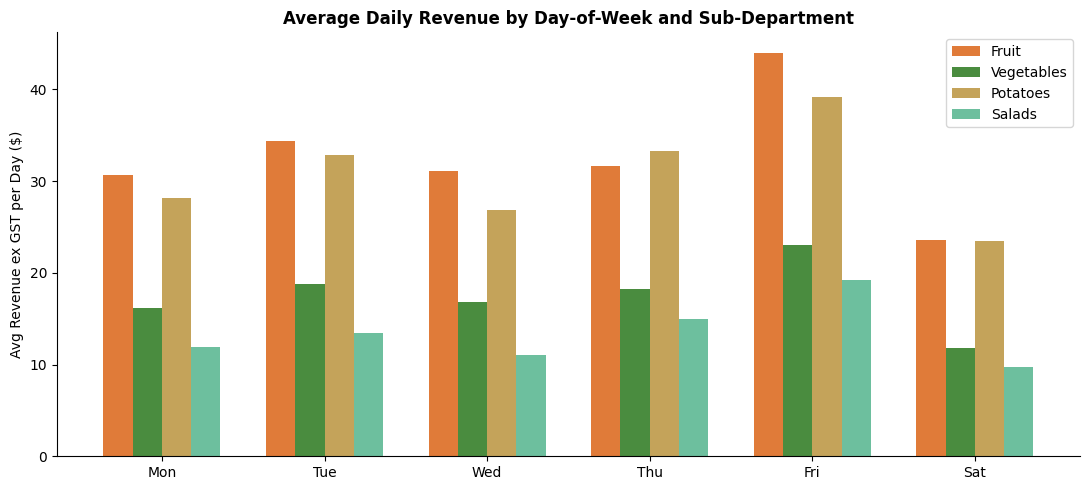


Avg revenue per day by DOW (all FV):
 day_of_week  day_name  sales_ex_gst
           0    Monday       2136.73
           1   Tuesday       2873.35
           2 Wednesday       2401.67
           3  Thursday       2477.67
           4    Friday       3901.21
           5  Saturday       1545.73


In [11]:
# ── DOW revenue by sub-dept ────────────────────────────────────────────────────
dow_data = (sales.groupby(['day_of_week','day_name','sub_dept_label'])
            ['sales_ex_gst'].mean().reset_index())
dow_data = dow_data[~dow_data['sub_dept_label'].isin(['None/Unknown','Fruit & Vege Department Open'])]
dow_pivot = dow_data.pivot(index='day_of_week', columns='sub_dept_label', values='sales_ex_gst').fillna(0)
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat']

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(dow_pivot))
width = 0.18
for i, col in enumerate(['Fruit','Vegetables','Potatoes','Salads']):
    ax.bar(x + i*width, dow_pivot[col], width, label=col, color=COLORS.get(col))
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(dow_labels)
ax.set_ylabel('Avg Revenue ex GST per Day ($)')
ax.set_title('Average Daily Revenue by Day-of-Week and Sub-Department')
ax.legend()
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / str(CHARTS_DIR / 'dow_subdept.png')), dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("\nAvg revenue per day by DOW (all FV):")
dow_total = sales.groupby(['date','day_name','day_of_week'])['sales_ex_gst'].sum().reset_index()
dow_avg = dow_total.groupby(['day_of_week','day_name'])['sales_ex_gst'].mean().reset_index().sort_values('day_of_week')
print(dow_avg.round(2).to_string(index=False))


## 5. ABC Item Classification

In [12]:
# ── ABC by revenue contribution ───────────────────────────────────────────────
item_rev = (sales.groupby(['name','sub_dept_label'])
            .agg(revenue=('sales_ex_gst','sum'),
                 selling_days=('date','nunique'))
            .sort_values('revenue', ascending=False)
            .reset_index())
item_rev['presence_pct'] = item_rev['selling_days'] / TRADING_DAYS * 100
total = item_rev['revenue'].sum()
item_rev['cum_share'] = item_rev['revenue'].cumsum() / total * 100
item_rev['ABC'] = pd.cut(item_rev['cum_share'], bins=[0,50,80,100], labels=['A','B','C'])

print("ABC classification across all FV (by revenue contribution):")
print(item_rev.groupby('ABC').agg(items=('name','count'), total_rev=('revenue','sum')).assign(
    rev_share=lambda d: d['total_rev']/total*100).round(2).to_string())

print("\nABC by sub-department:")
print(item_rev.groupby(['sub_dept_label','ABC'])['name'].count().unstack().fillna(0).astype(int).to_string())


ABC classification across all FV (by revenue contribution):
     items  total_rev  rev_share
ABC                             
A       20  115608.03      49.24
B       43   72100.16      30.71
C      179   47094.00      20.06

ABC by sub-department:
ABC                            A   B   C
sub_dept_label                          
Fruit                         10  16  51
Fruit & Vege Department Open   0   1   4
None/Unknown                   0   1   7
Potatoes                       3   5   6
Salads                         1   5  46
Vegetables                     6  15  65


Regular items (≥25% presence):     145 items, $227,343 revenue
Intermittent items (<25% presence): 99 items, $7,462 revenue
Intermittent share of total items:  40.6%

Intermittent items by sub-dept:
sub_dept_label
Salads                          33
Fruit                           26
Vegetables                      24
None/Unknown                     7
Fruit & Vege Department Open     5
Potatoes                         4
Name: name, dtype: int64


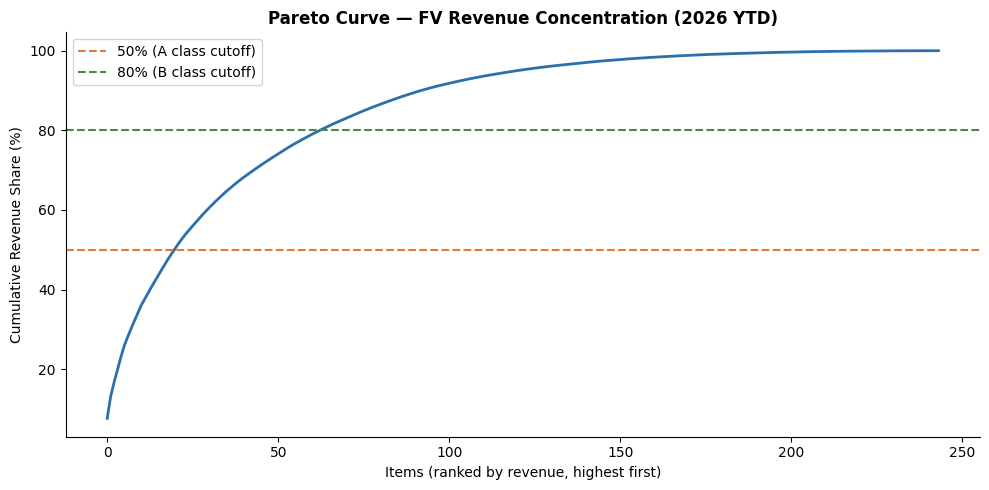

In [13]:
# ── Intermittent items (<25% presence) ───────────────────────────────────────
intermittent = item_rev[item_rev['presence_pct'] < 25]
regular      = item_rev[item_rev['presence_pct'] >= 25]

print(f"Regular items (≥25% presence):     {len(regular)} items, ${regular['revenue'].sum():,.0f} revenue")
print(f"Intermittent items (<25% presence): {len(intermittent)} items, ${intermittent['revenue'].sum():,.0f} revenue")
print(f"Intermittent share of total items:  {len(intermittent)/len(item_rev)*100:.1f}%")

print("\nIntermittent items by sub-dept:")
print(intermittent.groupby('sub_dept_label')['name'].count().sort_values(ascending=False))

# Cumulative revenue curve
fig, ax = plt.subplots(figsize=(10, 5))
item_rev_sorted = item_rev.sort_values('revenue', ascending=False).reset_index(drop=True)
ax.plot(range(len(item_rev_sorted)), item_rev_sorted['cum_share'], color='#2c6fad', linewidth=2)
ax.axhline(50, color='#e07b39', linestyle='--', label='50% (A class cutoff)')
ax.axhline(80, color='#4a8c3f', linestyle='--', label='80% (B class cutoff)')
ax.set_xlabel('Items (ranked by revenue, highest first)')
ax.set_ylabel('Cumulative Revenue Share (%)')
ax.set_title('Pareto Curve — FV Revenue Concentration (2026 YTD)')
ax.legend()
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / str(CHARTS_DIR / 'pareto_curve.png')), dpi=150, bbox_inches='tight')
plt.show()


## 6. Margin Analysis — GP% Distribution and Margin Traps

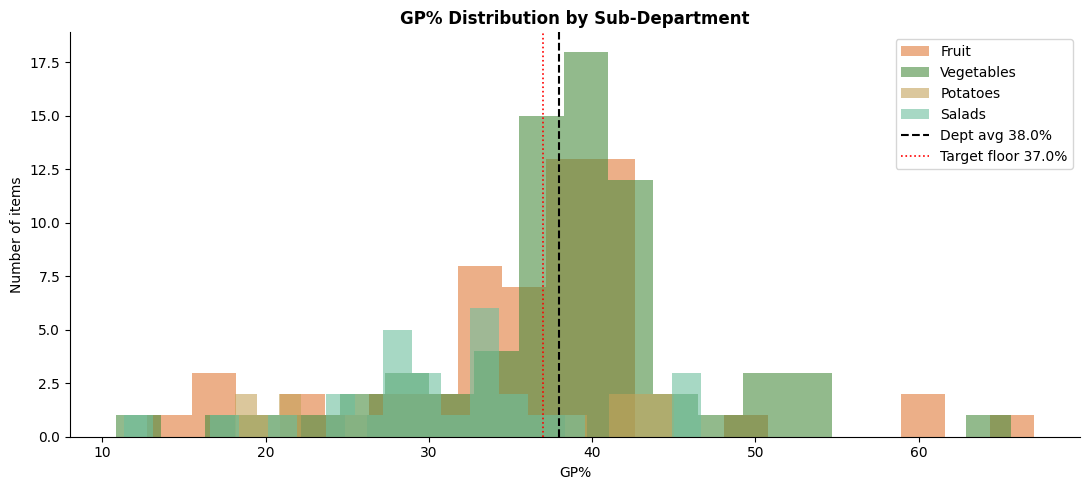

In [14]:
# ── GP distribution by sub-dept ──────────────────────────────────────────────
item_gp = (sales.groupby(['name','sub_dept_label'])
           .agg(rev=('sales_ex_gst','sum'), gp=('gp_dollars','sum'))
           .assign(gp_pct=lambda d: d['gp']/d['rev']*100)
           .reset_index())
item_gp = item_gp[item_gp['rev'] > 100]  # filter low-volume noise

fig, ax = plt.subplots(figsize=(11, 5))
for sub in ['Fruit','Vegetables','Potatoes','Salads']:
    d = item_gp[item_gp['sub_dept_label'] == sub]['gp_pct']
    ax.hist(d, bins=20, alpha=0.6, label=sub, color=COLORS.get(sub))
ax.axvline(38.0, color='black', linestyle='--', linewidth=1.5, label='Dept avg 38.0%')
ax.axvline(37.0, color='red', linestyle=':', linewidth=1.2, label='Target floor 37.0%')
ax.set_xlabel('GP%')
ax.set_ylabel('Number of items')
ax.set_title('GP% Distribution by Sub-Department')
ax.legend()
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / str(CHARTS_DIR / 'gp_distribution.png')), dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# ── Margin trap items (GP < 20%, revenue > $200) ─────────────────────────────
traps = item_gp[(item_gp['gp_pct'] < 20) & (item_gp['rev'] > 200)].sort_values('gp_pct')
print(f"Margin trap items (GP < 20%, revenue > $200): {len(traps)}")
print(traps[['name','sub_dept_label','rev','gp_pct','gp']].round(2).to_string(index=False))


Margin trap items (GP < 20%, revenue > $200): 10
                              name               sub_dept_label     rev  gp_pct     gp
               REDUCED FRUIT & VEG Fruit & Vege Department Open 1423.50   10.35 147.28
                 P/PICK LIMES 400G                        Fruit  432.28   12.74  55.08
                 P/PICK LEMON 500G                        Fruit  212.15   16.80  35.65
                     GARLIC PER KG                   Vegetables  743.30   17.29 128.49
                  P/PICK AVOCADOES                        Fruit 1923.90   17.29 332.70
              P/PICK NECTARINE 1KG                        Fruit  272.80   17.78  48.50
      COMM CO SALAD KIT THAI 285GM                       Salads  812.20   17.81 144.66
  POTATOES - MITOLO LOW CARB 1.5KG                     Potatoes 1098.39   18.13 199.13
POTATOES - MITOLO ROYAL BLUE 1.5KG                     Potatoes  277.86   18.38  51.06
                     GINGER PER KG                   Vegetables  474.65   19.57  

In [16]:
# ── Salads sub-dept — flag low-GP lines ───────────────────────────────────────
salads_gp = item_gp[item_gp['sub_dept_label'] == 'Salads'].sort_values('gp_pct')
print("All Salads items by GP% (lowest first):")
print(salads_gp[['name','rev','gp_pct','gp']].round(2).to_string(index=False))


All Salads items by GP% (lowest first):
                                 name     rev  gp_pct      gp
                S/TASTY SLD EGG 250GM  111.62   11.31   12.62
         COMM CO SALAD KIT THAI 285GM  812.20   17.81  144.66
           COMM CO KALESLAW KIT 400GM  638.04   20.56  131.19
         BOWLSOME CHICKEN CAESAR 225G  397.11   23.81   94.56
BOWLSOME LEMONGRASS CHICK NOODLE 330G  155.01   23.98   37.17
      BOWLSOME CHICKEN PAD THAI 300GM  182.61   26.62   48.61
     BOWLSOME ASIAN CHICKEN SLAW 290G  210.26   27.28   57.35
        L/C LENTIL CHICKPEA TABBOULEH  151.73   27.91   42.35
      R/BOW FRESH MESCULIN MIX 120GMS 1257.11   27.94  351.21
        COMM CO CRNCHY NDLE KIT 450GM  704.90   28.00  197.40
       BOWLSOME ASIAN BEEF SALAD 290G  203.92   28.91   58.96
         R/BOW FRESH WILD ROCKET 120G  205.28   29.46   60.48
       S/TASTY SLD PSTA CKN&BCN 300GM  115.72   29.55   34.19
         R/BOW FRESH SWEET MIX 120GMS 1318.22   30.62  403.62
                 LK POTATO SAL

## 7. Waste: Dump Stock Analysis (All Departments)

In [17]:
# ── Cross-department dump summary ────────────────────────────────────────────
dump_summary = (dump.groupby('Department')
                .agg(lines=('Qty','count'),
                     total_qty=('Qty','sum'),
                     total_cost=('Total Cost ex','sum'),
                     total_sell_ex=('Total Sell ex','sum'))
                .round(2))
print("Dump Stock Summary (Jan–Apr 2026):")
print(dump_summary.to_string())


Dump Stock Summary (Jan–Apr 2026):
             lines  total_qty  total_cost  total_sell_ex
Department                                              
DAIRY          289      844.0     2936.83        4157.13
FRUIT & VEG    143      331.0     1407.46        2146.44
MEAT            45      142.0     1830.20        2802.51


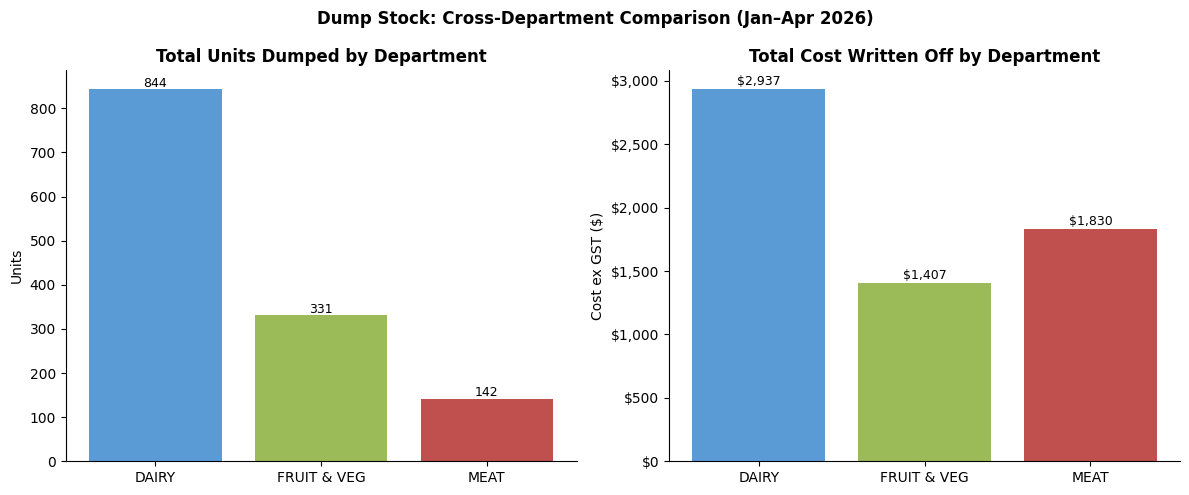

In [18]:
# ── Department comparison: dumps ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

depts = dump_summary.index.tolist()
cols_d = [COLORS.get(d) for d in depts]

axes[0].bar(depts, dump_summary['total_qty'], color=cols_d)
axes[0].set_title('Total Units Dumped by Department')
axes[0].set_ylabel('Units')
for i, (d, v) in enumerate(zip(depts, dump_summary['total_qty'])):
    axes[0].text(i, v + 5, f'{v:.0f}', ha='center', fontsize=9)

axes[1].bar(depts, dump_summary['total_cost'], color=cols_d)
axes[1].set_title('Total Cost Written Off by Department')
axes[1].set_ylabel('Cost ex GST ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, (d, v) in enumerate(zip(depts, dump_summary['total_cost'])):
    axes[1].text(i, v + 30, f'${v:,.0f}', ha='center', fontsize=9)

plt.suptitle('Dump Stock: Cross-Department Comparison (Jan–Apr 2026)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / str(CHARTS_DIR / 'dump_dept_comparison.png')), dpi=150, bbox_inches='tight')
plt.show()


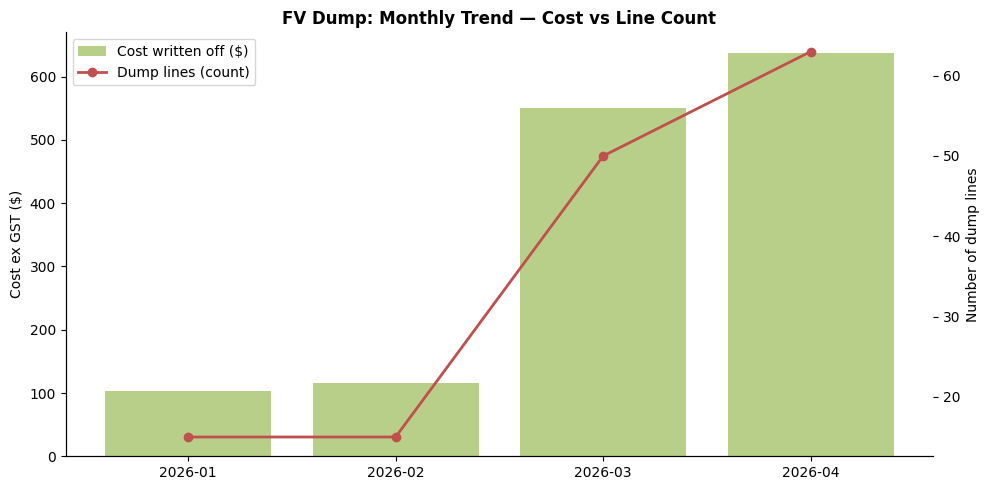


FV Monthly dump detail:
  Month  lines   qty   cost Month_str
2026-01     15  33.0 103.04   2026-01
2026-02     15  31.0 115.14   2026-02
2026-03     50 121.0 551.14   2026-03
2026-04     63 146.0 638.14   2026-04


In [19]:
# ── FV dump monthly trend ─────────────────────────────────────────────────────
fv_dump = dump[dump['Department'] == 'FRUIT & VEG'].copy()
monthly_dump = (fv_dump.groupby('Month')
                .agg(lines=('Qty','count'), qty=('Qty','sum'), cost=('Total Cost ex','sum'))
                .reset_index())
monthly_dump['Month_str'] = monthly_dump['Month'].astype(str)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
bars = ax1.bar(monthly_dump['Month_str'], monthly_dump['cost'],
               color=COLORS['FRUIT & VEG'], alpha=0.7, label='Cost written off ($)')
ax2.plot(monthly_dump['Month_str'], monthly_dump['lines'],
         color='#c0504d', marker='o', linewidth=2, label='Dump lines (count)')
ax1.set_ylabel('Cost ex GST ($)')
ax2.set_ylabel('Number of dump lines')
ax1.set_title('FV Dump: Monthly Trend — Cost vs Line Count')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / str(CHARTS_DIR / 'fv_dump_monthly.png')), dpi=150, bbox_inches='tight')
plt.show()

print("\nFV Monthly dump detail:")
print(monthly_dump.round(2).to_string(index=False))


In [20]:
# ── Top FV items dumped ───────────────────────────────────────────────────────
top_dump_fv = (fv_dump.groupby('Description')
               .agg(events=('Qty','count'), qty=('Qty','sum'), cost=('Total Cost ex','sum'),
                    reason=('Reason', lambda x: ', '.join(sorted(x.unique()))))
               .sort_values('cost', ascending=False)
               .head(20))
print("Top 20 FV items by cost dumped:")
print(top_dump_fv.round(2).to_string())


Top 20 FV items by cost dumped:
                                       events   qty   cost            reason
Description                                                                 
BOWLSOME ASIAN CHICKEN SLAW 290G            4  12.0  88.64           Expired
LK POTATO SALAD 800G                        4  13.0  63.75  Damaged, Expired
BOWLSOME LEMONGRASS CHICK NOODLE 330G       4   8.0  59.44  Damaged, Expired
LK COLESLAW SALAD 800G                      5  12.0  59.16  Damaged, Expired
S/TASTY SLD ASIAN STY RC 300GM              3  13.0  58.50  Damaged, Expired
BOWLSOME mexican chicken fajita 350gm       2   7.0  55.65  Damaged, Expired
BOWLSOME CHICKEN Pad Thai 300gm             3   7.0  55.55  Damaged, Expired
BOWLSOME CHICKEN CAESAR 225G                3   7.0  49.93  Damaged, Expired
HERBS - FRESH ASSTD VARIETIES               7  19.0  47.00           Expired
L/C LENTIL CHICKPEA TABBOULEH               4  12.0  45.26  Damaged, Expired
GOURMET GDN CHILLI PASTE 80G                

In [21]:
# ── Dump reason breakdown ─────────────────────────────────────────────────────
reason_dept = (dump.groupby(['Department','Reason'])
               .agg(qty=('Qty','sum'), cost=('Total Cost ex','sum'))
               .reset_index())
print("Dump reasons by department:")
print(reason_dept.pivot(index='Department', columns='Reason', values='cost').round(2).to_string())


Dump reasons by department:
Reason       Damaged  Expired  Store Use
Department                              
DAIRY         340.60  2596.23        NaN
FRUIT & VEG   345.33  1058.13        4.0
MEAT          494.72  1335.48        NaN


## 8. Waste: Markdown Analysis (All Departments)

In [22]:
# ── Cross-department markdown summary ────────────────────────────────────────
md_summary = (markdowns.groupby('Department')
              .agg(lines=('Qty','count'),
                   total_qty=('Qty','sum'),
                   potential_sell=('Potential Sell','sum'),
                   total_sell=('Total Sell','sum'),
                   discount_given=('Discount Given','sum'),
                   total_cost=('Total Cost','sum'),
                   realised_profit=('Realised Profit','sum'))
              .round(2))
md_summary['recovery_pct'] = (md_summary['total_sell'] / md_summary['potential_sell'] * 100).round(1)
print("Markdown Summary (Jan–Apr 2026):")
print(md_summary.to_string())


Markdown Summary (Jan–Apr 2026):
             lines  total_qty  potential_sell  total_sell  discount_given  total_cost  realised_profit  recovery_pct
Department                                                                                                          
DAIRY          152      850.0         4591.51     2397.75         2193.76     2889.39          -470.24          52.2
FRUIT & VEG     68      640.0         3666.81     1948.62         1718.19     2285.50          -339.61          53.1
MEAT            43      347.0        20539.72    14465.22         6074.50    13552.71           912.23          70.4


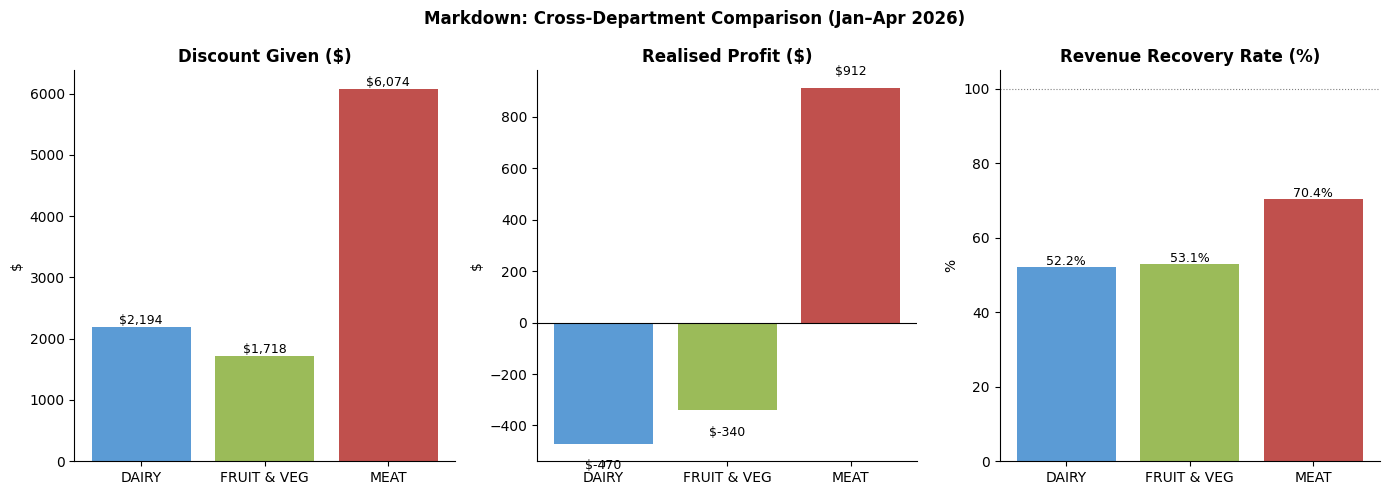

In [23]:
# ── Cross-department markdown chart ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

depts = md_summary.index.tolist()
cols_d = [COLORS.get(d) for d in depts]

axes[0].bar(depts, md_summary['discount_given'], color=cols_d)
axes[0].set_title('Discount Given ($)')
axes[0].set_ylabel('$')
for i, v in enumerate(md_summary['discount_given']):
    axes[0].text(i, v + 50, f'${v:,.0f}', ha='center', fontsize=9)

axes[1].bar(depts, md_summary['realised_profit'], color=cols_d)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Realised Profit ($)')
axes[1].set_ylabel('$')
for i, v in enumerate(md_summary['realised_profit']):
    axes[1].text(i, v + 50 if v >= 0 else v - 100, f'${v:,.0f}', ha='center', fontsize=9)

axes[2].bar(depts, md_summary['recovery_pct'], color=cols_d)
axes[2].set_title('Revenue Recovery Rate (%)')
axes[2].set_ylabel('%')
axes[2].axhline(100, color='grey', linestyle=':', linewidth=0.8)
for i, v in enumerate(md_summary['recovery_pct']):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Markdown: Cross-Department Comparison (Jan–Apr 2026)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / str(CHARTS_DIR / 'markdown_dept_comparison.png')), dpi=150, bbox_inches='tight')
plt.show()


In [24]:
# ── FV markdown: top items by discount given ──────────────────────────────────
fv_md = markdowns[markdowns['Department'] == 'FRUIT & VEG'].copy()

print(f"FV Markdown totals:")
print(f"  Lines:             {len(fv_md)}")
print(f"  Units:             {fv_md['Qty'].sum():.0f}")
print(f"  Potential sell:    ${fv_md['Potential Sell'].sum():,.2f}")
print(f"  Actual sell:       ${fv_md['Total Sell'].sum():,.2f}")
print(f"  Discount given:    ${fv_md['Discount Given'].sum():,.2f}")
print(f"  Realised profit:   ${fv_md['Realised Profit'].sum():,.2f}")
print(f"  Avg GP%:           {fv_md['GP'].mean():.1f}%")

print("\nTop 20 FV items by discount given:")
top_md = fv_md.nlargest(20,'Discount Given')[['Description','Qty','Potential Sell','Total Sell','Discount Given','Realised Profit','GP']]
print(top_md.round(2).to_string(index=False))


FV Markdown totals:
  Lines:             75
  Units:             640
  Potential sell:    $3,666.81
  Actual sell:       $1,948.62
  Discount given:    $1,718.19
  Realised profit:   $-339.61
  Avg GP%:           -18.7%

Top 20 FV items by discount given:
                     Description  Qty  Potential Sell  Total Sell  Discount Given  Realised Profit     GP
 R/BOW FRESH MESCULIN MIX 120GMS 81.0          323.19      157.78          165.41           -39.02 -24.73
  MUSHROOM - PREPACK BUTTON 200G 48.0          234.72      110.28          124.44           -28.92 -26.22
         STRAWBERRIES PER PUNNET 46.0          323.54      210.17          113.37             3.52   1.67
    R/BOW FRESH SWEET MIX 120GMS 52.0          207.48      105.11          102.37           -19.79 -18.83
  COMM CO KALESLAW KIT     400GM 24.0          156.00       79.04           76.96           -32.56 -41.19
MUSHROOMS - SLICED  200G PREPACK 29.0          141.81       65.27           76.54           -18.83 -28.85
  

In [25]:
# ── FV markdown: worst GP% items ─────────────────────────────────────────────
worst_gp = fv_md[fv_md['Qty'].notna()].nsmallest(15,'GP')[['Description','Qty','Total Sell','Discount Given','GP']]
print("FV markdown items with worst GP% (selling below cost):")
print(worst_gp.round(2).to_string(index=False))


FV markdown items with worst GP% (selling below cost):
                            Description  Qty  Total Sell  Discount Given     GP
         COMM CO SALAD CRMY RNCH  350GM  5.0       12.00           17.95 -69.30
                MUSHROOMS - SLICED 500G  5.0       16.00           23.95 -62.50
              LK ASIAN SESAME KIT 350GM  1.0        2.00            2.99 -60.65
        GOURMET GDN THAI STYLEPASTE 80G  1.0        3.20            4.79 -60.47
            GOURMET GDN BASIL PASTE 80G  1.0        3.20            4.79 -60.47
         COMM CO SALAD KIT THAI   285GM 21.0       71.96           74.83 -53.39
         S/TASTY SLD EGG          250GM  4.0       14.46           13.50 -52.14
  BOWLSOME mexican chicken fajita 350gm  1.0        5.24            5.25 -51.72
              HI FRESH KALESLAW  350GMS  3.0        7.76           12.91 -51.16
HI FRESH CRUNCHY ASIAN SALAD KIT 300GMS  2.0        4.90            7.08 -51.02
           THE PERFECT SWEET MIX 120GMS  2.0        2.64         

## 9. Combined Waste Picture

Combined waste cost by department (Jan–Apr 2026):
             Dump Cost  Markdown Loss  Total Waste Cost
Department                                             
DAIRY          2936.83         470.24           3407.07
FRUIT & VEG    1407.46         339.61           1747.06
MEAT           1830.20           0.00           1830.20


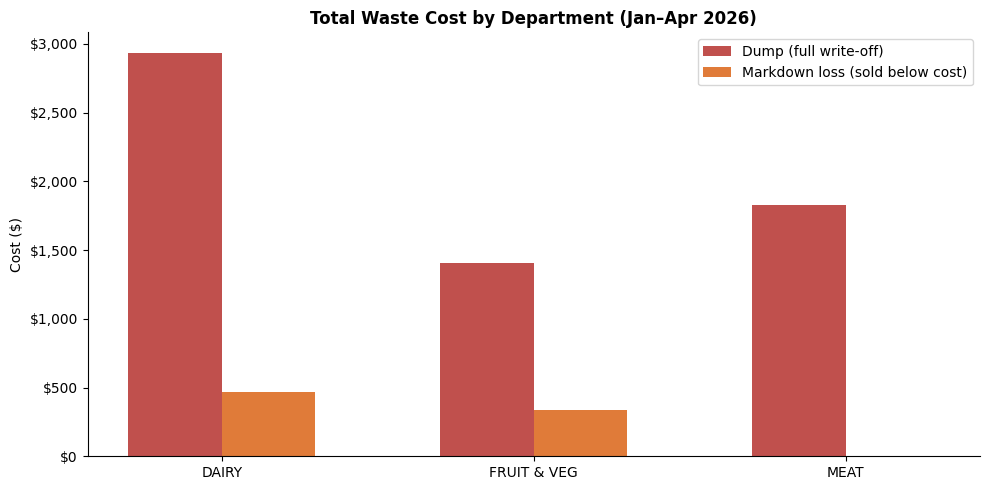

In [26]:
# ── Total waste cost by department ────────────────────────────────────────────
# Dump = cost fully written off
# Markdown = negative realised profit (markdown below cost of goods)

dump_cost   = dump.groupby('Department')['Total Cost ex'].sum()
md_loss     = markdowns.groupby('Department')['Realised Profit'].sum().clip(upper=0).abs()

combined = pd.DataFrame({'Dump Cost': dump_cost, 'Markdown Loss': md_loss}).fillna(0)
combined['Total Waste Cost'] = combined['Dump Cost'] + combined['Markdown Loss']

print("Combined waste cost by department (Jan–Apr 2026):")
print(combined.round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(combined))
w = 0.3
ax.bar(x - w/2, combined['Dump Cost'],    w, label='Dump (full write-off)',   color='#c0504d')
ax.bar(x + w/2, combined['Markdown Loss'],w, label='Markdown loss (sold below cost)', color='#e07b39')
ax.set_xticks(x)
ax.set_xticklabels(combined.index)
ax.set_ylabel('Cost ($)')
ax.set_title('Total Waste Cost by Department (Jan–Apr 2026)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / str(CHARTS_DIR / 'combined_waste.png')), dpi=150, bbox_inches='tight')
plt.show()


In [27]:
# ── Items appearing in both dump AND markdown (chronic over-orders) ───────────
# These items were BOTH fully written off (dumped) AND sold on markdown in the same period.
# Both signals point to the same root cause: over-ordering / poor shelf-life management.
dump_fv_items  = set(fv_dump['Description'].str.strip().str.upper())
md_fv_items    = set(fv_md['Description'].str.strip().str.upper())
overlap = dump_fv_items & md_fv_items

print(f"FV items appearing in BOTH dump and markdown lists: {len(overlap)}")
print("\nTop priority for order quantity reductions (present in both waste streams):")
for item in sorted(overlap):
    print(f"  • {item}")


FV items appearing in BOTH dump and markdown lists: 44

Top priority for order quantity reductions (present in both waste streams):
  • ALFALFA/SPROUTS PER TUB
  • ASPARAGUS PER BUNCH
  • BEAN SPROUTS 125GMS
  • BEAN SPROUTS 350G BAG
  • BOWLSOME CHICKEN CAESAR 225G
  • BOWLSOME LEMONGRASS CHICK NOODLE 330G
  • BOWLSOME MEXICAN CHICKEN FAJITA 350GM
  • COMM CO COLESLAW         200GM
  • COMM CO CRNCHY NDLE KIT  450GM
  • COMM CO KALESLAW KIT     400GM
  • COMM CO SALAD CRMY RNCH  350GM
  • COMM CO SALAD KIT THAI   285GM
  • CUCUMBER BABY LEBANESE P/PACK 250GMS
  • FRESH HERBS
  • FRUIT SALAD PLATTER
  • GOURMET GDN BASIL PASTE 80G
  • GOURMET GDN THAI STYLEPASTE 80G
  • HERBS - FRESH ASSTD VARIETIES
  • HI FRESH CRUNCHY ASIAN SALAD 370GMS
  • HI FRESH GREEK SALAD KIT 180GMS
  • HI FRESH KALESLAW  350GMS
  • HI FRESH MESCLUN 180GMS
  • L/C CAESAR BOWL
  • L/C LENTIL CHICKPEA TABBOULEH
  • LK COLESLAW SALAD 250G
  • LK COLESLAW SALAD 800G
  • LK PASTA SALAD 800G
  • LK POTATO SALAD 250G


In [28]:
# ── Waste as % of FV revenue ──────────────────────────────────────────────────
fv_dump_cost = dump[dump['Department'] == 'FRUIT & VEG']['Total Cost ex'].sum()
fv_md_loss   = markdowns[markdowns['Department'] == 'FRUIT & VEG']['Realised Profit'].clip(upper=0).abs().sum()
total_waste_cost = fv_dump_cost + fv_md_loss
waste_pct_rev    = total_waste_cost / total_rev * 100

print(f"FV department waste summary (Jan–Apr 2026):")
print(f"  Total revenue:               ${total_rev:>10,.2f}")
print(f"  Dump cost (write-offs):      ${fv_dump_cost:>10,.2f}")
print(f"  Markdown losses:             ${fv_md_loss:>10,.2f}")
print(f"  Total waste cost:            ${total_waste_cost:>10,.2f}")
print(f"  Waste as % of revenue:       {waste_pct_rev:>10.2f}%")
print(f"  Target: < 5.0%               {'✓ ON TARGET' if waste_pct_rev < 5 else '✗ OVER TARGET'}")


FV department waste summary (Jan–Apr 2026):
  Total revenue:               $234,805.39
  Dump cost (write-offs):      $  1,407.46
  Markdown losses:             $    376.62
  Total waste cost:            $  1,784.08
  Waste as % of revenue:             0.76%
  Target: < 5.0%               ✓ ON TARGET


## 10. Key Findings & Recommendations

### Revenue & GP
- **Fruit** drives 49% of FV revenue ($115K) at 37.1% GP — healthy but GP is the lowest of the main sub-depts.
- **Vegetables** contribute 32% ($76K) at 39.7% GP — the most margin-efficient sub-department.
- **Potatoes** punch above their weight: 14 items generating $21K (9%) at 38.1% GP. Compact, high-efficiency range.
- **Salads** ($19K, 32.1% GP) is the weakest sub-department on margin. Several lines (Comm Co Thai Kit, Kaleslaw Kit) run GP below 20% — these are also chronic waste items.
- **Open-ring / unclassified** lines (~$3.8K) inflate "None" sub_dept. Fixing PLU assignment would reclassify these correctly.

### Day-of-Week
- Friday is the dominant trading day across all sub-departments. Friday afternoon demand (pre-weekend) drives ordering decisions for the Friday → Tuesday delivery cycle.
- Saturday revenue is roughly half Friday despite similar opening hours — customers likely front-load purchases on Friday.

### ABC Classification
- **A-class (top 50% revenue):** Only 10 Fruit items and 6 Vegetable items account for half the department's total revenue. These 16 items are mission-critical for in-stock performance.
- **Salads** has 46 C-class items generating only $9K combined. The long tail is carrying inventory risk with low revenue justification.
- Intermittent items (< 25% presence): 33 Salads items, 26 Fruit items, 24 Vegetables items. These should be managed with minimum-stock rules, not volume forecasts.

### Margin Traps (GP < 20%)
- **Pre-packed avocadoes** (17.3% GP, $1.9K revenue) and **Mitolo Low Carb Potatoes** (18.1% GP) are systematic under-performers. Review pricing.
- **Comm Co Thai Salad Kit** (17.8% GP in POS sales, and the worst markdown GP at -53%) is losing money at full price AND on markdown.

### Waste — Dump (Full Write-offs)
- **DAIRY** is the worst department for dump volume (289 lines, 844 units, $2,937 cost).
- **FRUIT & VEG** accelerated sharply: 15 lines/month Jan–Feb → 63 lines in April alone. This is the clearest evidence the over-ordering problem is still active.
- Top FV dump items: fresh herb packs, LK salads, Bowlsome ready meals, prepack mushrooms. All short shelf-life, all high event count.

### Waste — Markdowns
- **DAIRY** leads again on discount cost ($2,194 given away).
- **FV markdowns** cost $1,718 in discount and ended with -$340 realised profit — the department sold markdown stock below cost of goods on average.
- **MEAT** is the only department with positive markdown profit (+$912), suggesting meat markdowns are well-managed (still above cost).


### Chronic Over-Order Items (in Both Dump AND Markdown)
44 FV items appear in both the dump list and the markdown list — meaning these items were simultaneously being written off entirely AND being sold at a discount within the same 17-week period. This is the clearest signal of systemic over-ordering. Key names: all Bowlsome and Comm Co kit ranges, LK salads, herb packs, mushrooms, snow peas, bean sprouts.

### Priority Actions
1. **Reduce FV dump lines** — accelerating from 15 → 63/month. Target: cut order quantities 15–20% on herb packs, prepared salads, prepack mushrooms, Bowlsome range.
2. **Audit Salads sub-dept** — 46 C-class items, several below-cost on markdown. Consider ranging out the bottom 10–15 SKUs.
3. **Fix PLU assignment** — ~$3.8K in "None" sub_dept cannot be tracked or forecast properly.
4. **Price review: Comm Co Thai Kit and Kaleslaw Kit** — losing money at full price AND on markdown. Either reprice to 40% GP target or delist.
5. **DAIRY waste** — not within this project's scope, but the dump and markdown data show DAIRY is the store's largest waste contributor by cost. Flag to management.
